In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

df = pd.read_csv('/kaggle/input/datasets/nurulaminchoudhury/mobiact/MobiAct_Full_Dataset.csv')
df

,acc_X,acc_Y,acc_Z,gyro_X,gyro_Y,gyro_Z,ori_X,ori_Y,ori_Z,fall_label
0,-1.407790,9.615114,-2.087744,5.700900,8.943068,8.509353,105.63398,-24.657568,-6.744515,Back-sitting-chair
1,-1.369483,9.557653,-2.001553,5.700900,0.748310,0.033292,108.72327,-24.557203,-5.664876,Back-sitting-chair
2,-1.244985,9.634268,-2.097321,-1.184468,0.758084,0.037568,104.84894,-25.342705,-7.173953,Back-sitting-chair
3,-1.283292,9.624691,-2.039860,-1.189355,0.756251,0.039095,104.16071,-27.788020,-7.492693,Back-sitting-chair
4,-1.254562,9.672575,-2.049437,-1.197601,0.747394,0.039401,103.48147,-28.281435,-7.805677,Back-sitting-chair
...,...,...,...,...,...,...,...,...,...,...
241426,-7.230489,-1.024718,6.244078,2.347250,-1.259910,-1.180192,251.91757,-6.430913,-29.185995,Sideward-lying
241427,-7.249643,-1.015141,6.272809,2.530815,-1.957212,-0.816421,252.50519,-5.644849,-29.181583,Sideward-lying
241428,-7.249643,-1.043872,6.320692,2.521957,-2.679866,-0.526260,252.99359,-4.944588,-29.100350,Sideward-lying
241429,-7.268796,-1.005565,6.301539,2.341752,-3.510032,-0.361327,253.42215,-4.257514,-29.082285,Sideward-lying


In [2]:
df.fall_label.unique()

array(['Back-sitting-chair', 'Forward-lying', 'Front-knees-lying',
       'Sideward-lying'], dtype=object)

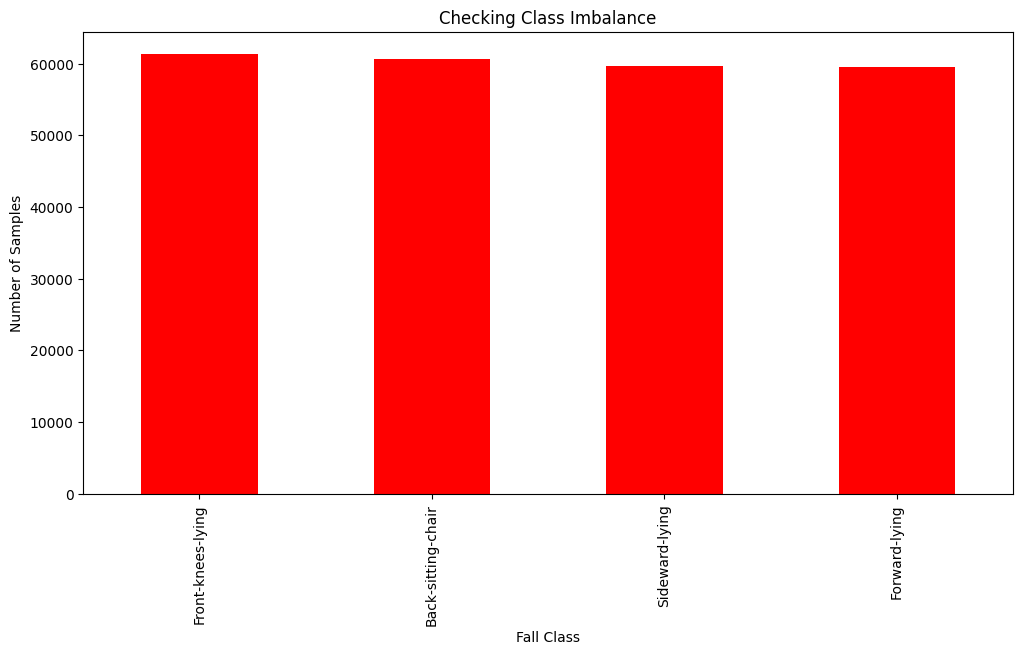

In [3]:
import missingno as msno
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
df['fall_label'].value_counts().plot(
    kind='bar',
    title='Checking Class Imbalance',
    color='red'
)
plt.xlabel('Fall Class')
plt.ylabel('Number of Samples')
plt.show()

In [4]:
from sklearn.preprocessing import LabelEncoder

# OPTIONAL: drop rows with missing or invalid labels
df = df[df['fall_label'].notna()].copy()

# Encode Fall_Class
le = LabelEncoder()
df['Fall_Class_Encoded'] = le.fit_transform(df['fall_label'])

# Print label mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("✅ Cleaned Label Mapping (Original → Encoded):")
for k, v in label_mapping.items():
    print(f"{k} → {v}")


✅ Cleaned Label Mapping (Original → Encoded):
Back-sitting-chair → 0
Forward-lying → 1
Front-knees-lying → 2
Sideward-lying → 3


In [5]:
df

,acc_X,acc_Y,acc_Z,gyro_X,gyro_Y,gyro_Z,ori_X,ori_Y,ori_Z,fall_label,Fall_Class_Encoded
0,-1.407790,9.615114,-2.087744,5.700900,8.943068,8.509353,105.63398,-24.657568,-6.744515,Back-sitting-chair,0
1,-1.369483,9.557653,-2.001553,5.700900,0.748310,0.033292,108.72327,-24.557203,-5.664876,Back-sitting-chair,0
2,-1.244985,9.634268,-2.097321,-1.184468,0.758084,0.037568,104.84894,-25.342705,-7.173953,Back-sitting-chair,0
3,-1.283292,9.624691,-2.039860,-1.189355,0.756251,0.039095,104.16071,-27.788020,-7.492693,Back-sitting-chair,0
4,-1.254562,9.672575,-2.049437,-1.197601,0.747394,0.039401,103.48147,-28.281435,-7.805677,Back-sitting-chair,0
...,...,...,...,...,...,...,...,...,...,...,...
241426,-7.230489,-1.024718,6.244078,2.347250,-1.259910,-1.180192,251.91757,-6.430913,-29.185995,Sideward-lying,3
241427,-7.249643,-1.015141,6.272809,2.530815,-1.957212,-0.816421,252.50519,-5.644849,-29.181583,Sideward-lying,3
241428,-7.249643,-1.043872,6.320692,2.521957,-2.679866,-0.526260,252.99359,-4.944588,-29.100350,Sideward-lying,3
241429,-7.268796,-1.005565,6.301539,2.341752,-3.510032,-0.361327,253.42215,-4.257514,-29.082285,Sideward-lying,3


In [6]:
df1 = df.drop(['fall_label'], axis=1)

df1.head()

,acc_X,acc_Y,acc_Z,gyro_X,gyro_Y,gyro_Z,ori_X,ori_Y,ori_Z,Fall_Class_Encoded
0,-1.407790,9.615114,-2.087744,5.700900,8.943068,8.509353,105.63398,-24.657568,-6.744515,0
1,-1.369483,9.557653,-2.001553,5.700900,0.748310,0.033292,108.72327,-24.557203,-5.664876,0
2,-1.244985,9.634268,-2.097321,-1.184468,0.758084,0.037568,104.84894,-25.342705,-7.173953,0
3,-1.283292,9.624691,-2.039860,-1.189355,0.756251,0.039095,104.16071,-27.788020,-7.492693,0
4,-1.254562,9.672575,-2.049437,-1.197601,0.747394,0.039401,103.48147,-28.281435,-7.805677,0


In [7]:
df1.Fall_Class_Encoded.unique()

array([0, 1, 2, 3])

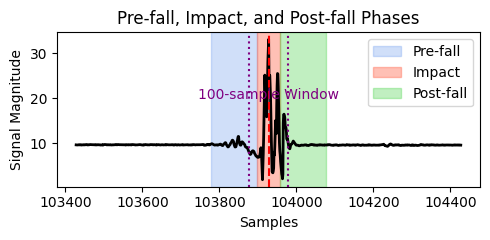

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Accelerometer channels
acc_x = df['acc_X'].values
acc_y = df['acc_Y'].values
acc_z = df['acc_Z'].values

# Signal Magnitude
smv = np.sqrt(acc_x**2 +
              acc_y**2 +
              acc_z**2)

# Find largest impact
impact_idx = np.argmax(smv)

# Zoom around impact
window = 500

start = max(0, impact_idx-window)
end = min(len(smv), impact_idx+window)

x = np.arange(start, end)
smv_zoom = smv[start:end]

# Define phases
pre_start = impact_idx-150
pre_end = impact_idx-30

impact_start = impact_idx-30
impact_end = impact_idx+30

post_start = impact_idx+30
post_end = impact_idx+150

plt.figure(figsize=(5,2.5))

plt.plot(x,
         smv_zoom,
         color='black',
         linewidth=2)

plt.axvspan(pre_start,
            pre_end,
            alpha=0.3,
            color='cornflowerblue',
            label='Pre-fall')

plt.axvspan(impact_start,
            impact_end,
            alpha=0.4,
            color='tomato',
            label='Impact')

plt.axvspan(post_start,
            post_end,
            alpha=0.3,
            color='limegreen',
            label='Post-fall')

plt.axvline(impact_idx,
            color='red',
            linestyle='--')

# 100-sample window
window_size = 100

seg_start = impact_idx-50
seg_end = impact_idx+50

plt.axvline(seg_start,
            color='purple',
            linestyle=':')

plt.axvline(seg_end,
            color='purple',
            linestyle=':')

plt.text((seg_start+seg_end)/2,
         np.max(smv_zoom)*0.6,
         '100-sample Window',
         color='purple',
         ha='center')

plt.xlabel('Samples')
plt.ylabel('Signal Magnitude')
plt.title('Pre-fall, Impact, and Post-fall Phases')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
df.columns

Index(['acc_X', 'acc_Y', 'acc_Z', 'gyro_X', 'gyro_Y', 'gyro_Z', 'ori_X',
       'ori_Y', 'ori_Z', 'fall_label', 'Fall_Class_Encoded'],
      dtype='object')

In [10]:

from scipy import stats

# -------------------------------------------------
# Step 2: Segmentation function
# -------------------------------------------------
def create_segments_and_labels(df, time_steps=100, step=10, label_col='Fall_Class_Encoded'):
    # Correct feature columns
    feature_columns = ['acc_X', 'acc_Y', 'acc_Z', 'gyro_X', 'gyro_Y', 'gyro_Z', 'ori_X',
       'ori_Y', 'ori_Z',]

    segments = []
    labels = []

    for i in range(0, len(df) - time_steps, step):
        # Windowed signal: (features, time_steps)
        segment = []
        for col in feature_columns:
            segment.append(df[col].values[i : i + time_steps])

        segment = np.array(segment)  # (9, time_steps)
        segments.append(segment)

        # Majority label in window
        label = stats.mode(
            df[label_col].iloc[i : i + time_steps],
            keepdims=True
        )[0][0]
        labels.append(label)

    # Final shape: (samples, time_steps, features)
    X = np.asarray(segments, dtype=np.float32).transpose(0, 2, 1)
    y = np.asarray(labels)

    return X, y

# -------------------------------------------------
# Step 3: Apply segmentation
# -------------------------------------------------
X, y = create_segments_and_labels(df, time_steps=100, step=10)

# -------------------------------------------------
# Step 4: Verify output
# -------------------------------------------------
print("Segmented Data Shape:", X.shape)   # (N, 200, 9)
print("Labels Shape:", y.shape)           # (N,)
print("Unique Labels:", np.unique(y))
print("Sample Labels:", y[:10])

Segmented Data Shape: (24134, 100, 9)
Labels Shape: (24134,)
Unique Labels: [0 1 2 3]
Sample Labels: [0 0 0 0 0 0 0 0 0 0]


In [11]:
from sklearn.model_selection import train_test_split

# Step 1: Stratified Train-Test Split
X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Step 2: Print dataset shapes
print("Training Data Shape:", X_train_res.shape, "| Labels:", y_train_res.shape)
print("Testing Data Shape :", X_test_res.shape,  "| Labels:", y_test_res.shape)



Training Data Shape: (19307, 100, 9) | Labels: (19307,)
Testing Data Shape : (4827, 100, 9) | Labels: (4827,)


In [13]:
#For Tetsing
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf


# ======================================================
# Noise Estimation Module
# ======================================================

def noise_estimation_module(inputs):

    x = layers.Conv1D(
        32,
        3,
        padding='same',
        activation='relu',
        name='noise_conv1'
    )(inputs)

    x = layers.BatchNormalization(
        name='noise_bn'
    )(x)

    noise = layers.Conv1D(
        filters=1,
        kernel_size=3,
        padding='same',
        activation='softplus',
        name='noise_map'          # IMPORTANT
    )(x)

    return noise


# ======================================================
# Noise-aware Gating
# ======================================================

def noise_aware_gating(features, noise, name):

    weight = layers.Lambda(
        lambda x: tf.exp(-x),
        name=name+"_weight"
    )(noise)

    gated = layers.Multiply(
        name=name+"_gated"
    )([features, weight])

    return gated


# ======================================================
# Noise-aware Transformer Encoder
# ======================================================

def noise_aware_transformer_encoder(
    inputs,
    noise,
    head_size,
    num_heads,
    ff_dim,
    dropout=0.01
):

    attn = layers.MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout,
        name='transformer_attention'
    )(inputs, inputs)

    noise_weight = layers.Lambda(
        lambda x: tf.exp(-x),
        name='transformer_noise_weight'
    )(noise)

    attn = layers.Multiply(
        name='transformer_noise_gating'
    )([attn, noise_weight])

    x = layers.Add(
        name='transformer_residual1'
    )([attn, inputs])

    x = layers.LayerNormalization(
        epsilon=1e-6,
        name='transformer_ln1'
    )(x)

    ffn = keras.Sequential([
        layers.Dense(
            ff_dim,
            activation='relu',
            name='ffn_dense1'
        ),
        layers.Dense(
            inputs.shape[-1],
            name='ffn_dense2'
        )
    ],
    name="transformer_ffn")

    x_ffn = ffn(x)

    x_ffn = layers.Multiply(
        name='transformer_ffn_gating'
    )([x_ffn, noise_weight])

    x = layers.Add(
        name='transformer_residual2'
    )([x_ffn, x])

    x = layers.LayerNormalization(
        epsilon=1e-6,
        name='transformer_output'
    )(x)

    return x


# ======================================================
# CNN Block
# ======================================================

def noise_aware_cnn_block(inputs,
                          noise,
                          filters,
                          kernel_size,
                          block_name):

    x = layers.Conv1D(
        filters,
        kernel_size,
        padding='same',
        activation='relu',
        name=block_name+"_conv"
    )(inputs)

    x = layers.BatchNormalization(
        name=block_name+"_bn"
    )(x)

    x = noise_aware_gating(
        x,
        noise,
        block_name
    )

    return x


# ======================================================
# NA-MSCT-Net
# ======================================================

def build_na_msct_net(
    input_shape=(100,9),
    num_classes=4
):

    inputs = keras.Input(
        shape=input_shape,
        name="sensor_input"
    )

    ##################################################

    noise = noise_estimation_module(inputs)

    ##################################################

    global_cnn = noise_aware_cnn_block(
        inputs,
        noise,
        64,
        3,
        "global_cnn"
    )

    ##################################################

    cnn3 = noise_aware_cnn_block(
        global_cnn,
        noise,
        64,
        3,
        "cnn3"
    )

    cnn5 = noise_aware_cnn_block(
        global_cnn,
        noise,
        64,
        5,
        "cnn5"
    )

    cnn7 = noise_aware_cnn_block(
        global_cnn,
        noise,
        64,
        7,
        "cnn7"
    )

    ##################################################

    transformer = noise_aware_transformer_encoder(
        global_cnn,
        noise,
        head_size=32,
        num_heads=2,
        ff_dim=64
    )

    ##################################################

    fusion = layers.Concatenate(
        name="feature_fusion"
    )([cnn3,
       cnn5,
       cnn7,
       transformer])

    ##################################################

    gap = layers.GlobalMaxPooling1D(
        name="global_pool"
    )(fusion)

    ##################################################

    embedding = layers.Dense(
        128,
        activation='relu',
        name="embedding_128"      # IMPORTANT
    )(gap)

    outputs = layers.Dense(
        num_classes,
        activation='softmax',
        name="classifier"
    )(embedding)

    ##################################################

    model = keras.Model(
        inputs,
        outputs,
        name="NA-MSCT-Net"
    )

    return model


# ======================================================
# Build Model
# ======================================================

model = build_na_msct_net(
    input_shape=(100,9),
    num_classes=4
)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

2026-07-28 07:10:20.149440: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785222620.322736      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785222620.377629      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1785222620.822115      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785222620.822144      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785222620.822147      58 computation_placer.cc:177] computation placer alr

Model: "NA-MSCT-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sensor_input        │ (None, 100, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_conv1         │ (None, 100, 32)   │        896 │ sensor_input[0][… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_bn            │ (None, 100, 32)   │        128 │ noise_conv1[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_cnn_conv     │ (None, 100, 64)   │      1,792 │ sensor_input[0][… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise_map (Conv1D)  │ (None, 100, 1)    │         97 │ noise_bn[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_cnn_bn       │ (None, 100, 64)   │        256 │ global_cnn_conv[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_cnn_weight   │ (None, 100, 1)    │          0 │ noise_map[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_cnn_gated    │ (None, 100, 64)   │          0 │ global_cnn_bn[0]… │
│ (Multiply)          │                   │            │ global_cnn_weigh… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_attent… │ (None, 100, 64)   │     16,640 │ global_cnn_gated… │
│ (MultiHeadAttentio… │                   │            │ global_cnn_gated… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_noise_… │ (None, 100, 1)    │          0 │ noise_map[0][0]   │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_noise_… │ (None, 100, 64)   │          0 │ transformer_atte… │
│ (Multiply)          │                   │            │ transformer_nois… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_residu… │ (None, 100, 64)   │          0 │ transformer_nois… │
│ (Add)               │                   │            │ global_cnn_gated… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_ln1     │ (None, 100, 64)   │        128 │ transformer_resi… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_ffn     │ (None, 100, 64)   │      8,320 │ transformer_ln1[… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn3_conv (Conv1D)  │ (None, 100, 64)   │     12,352 │ global_cnn_gated… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn5_conv (Conv1D)  │ (None, 100, 64)   │     20,544 │ global_cnn_gated… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn7_conv (Conv1D)  │ (None, 100, 64)   │     28,736 │ global_cnn_gated… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_ffn_ga… │ (None, 100, 64)   │          0 │ transformer_ffn[… │
│ (Multiply)          │                   │            │ transformer_nois

 Total params: 124,197 (485.14 KB)

 Trainable params: 123,621 (482.89 KB)

 Non-trainable params: 576 (2.25 KB)

In [14]:
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint



# Noise Function
def add_noise(X, noise_level=0.02):
    noise = np.random.normal(0, noise_level, X.shape)
    return X + noise

# Create Noisy Training Data
X_train_noisy = add_noise(X_train_res, noise_level=0.02)


X_combined = np.concatenate([X_train_res, X_train_noisy])
y_combined = np.concatenate([y_train_res, y_train_res])

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True
    ),
    
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6
    ),
    
    ModelCheckpoint(
        filepath='best_na_msct_model.h5',
        monitor='val_accuracy',
        save_best_only=True
    )
]


history = model.fit(
    X_combined,
    y_combined,
    validation_data=(X_test_res, y_test_res),
    epochs=100,
    batch_size=128,
    callbacks=callbacks,
    verbose=1)

Epoch 1/100


I0000 00:00:1785222641.115875     134 service.cc:152] XLA service 0x7e8130009800 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785222641.115910     134 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1785222642.260864     134 cuda_dnn.cc:529] Loaded cuDNN version 91002


 22/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3395 - loss: 1.9490

I0000 00:00:1785222648.564897     134 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5582 - loss: 1.0929

...

302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9956 - loss: 0.0141 - val_accuracy: 0.9890 - val_loss: 0.0323 - learning_rate: 2.5000e-04
Epoch 30/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9973 - loss: 0.0101

302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9963 - loss: 0.0115 - val_accuracy: 0.9905 - val_loss: 0.0337 - learning_rate: 2.5000e-04
Epoch 31/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9963 - loss: 0.0112 - val_accuracy: 0.9892 - val_loss: 0.0343 - learning_rate: 2.5000e-04
Epoch 32/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9952 - loss: 0.0136 - val_accuracy: 0.9882 - val_loss: 0.0388 - learning_rate: 2.5000e-04
Epoch 33/100
297/302 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9958 - loss: 0.0130

302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9948 - loss: 0.0147 - val_accuracy: 0.9909 - val_loss: 0.0355 - learning_rate: 2.5000e-04
Epoch 34/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9952 - loss: 0.0132 - val_accuracy: 0.9903 - val_loss: 0.0331 - learning_rate: 2.5000e-04
Epoch 35/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9979 - loss: 0.0082 - val_accuracy: 0.9903 - val_loss: 0.0335 - learning_rate: 1.2500e-04
Epoch 36/100
297/302 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9982 - loss: 0.0070

302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9981 - loss: 0.0070 - val_accuracy: 0.9913 - val_loss: 0.0324 - learning_rate: 1.2500e-04
Epoch 37/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9982 - loss: 0.0069 - val_accuracy: 0.9892 - val_loss: 0.0357 - learning_rate: 1.2500e-04
Epoch 38/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9977 - loss: 0.0079 - val_accuracy: 0.9905 - val_loss: 0.0331 - learning_rate: 1.2500e-04
Epoch 39/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9979 - loss: 0.0069 - val_accuracy: 0.9898 - val_loss: 0.0324 - learning_rate: 1.2500e-04
Epoch 40/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9986 - loss: 0.0053 - val_accuracy: 0.9911 - val_loss: 0.0287 - learning_rate: 6.2500e-05
Epoch 41/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9988 - loss: 0.0053 - val_accuracy: 0.9901 - val_loss: 0.0292 - learning_rate: 6.2500e-05
Epoch 42/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy:

302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9988 - loss: 0.0052 - val_accuracy: 0.9915 - val_loss: 0.0301 - learning_rate: 6.2500e-05
Epoch 45/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9988 - loss: 0.0050 - val_accuracy: 0.9909 - val_loss: 0.0320 - learning_rate: 6.2500e-05
Epoch 46/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9990 - loss: 0.0046 - val_accuracy: 0.9913 - val_loss: 0.0291 - learning_rate: 3.1250e-05
Epoch 47/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9990 - loss: 0.0044 - val_accuracy: 0.9913 - val_loss: 0.0288 - learning_rate: 3.1250e-05
Epoch 48/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9990 - loss: 0.0045 - val_accuracy: 0.9911 - val_loss: 0.0301 - learning_rate: 3.1250e-05
Epoch 49/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9991 - loss: 0.0041 - val_accuracy: 0.9907 - val_loss: 0.0299 - learning_rate: 3.1250e-05
Epoch 50/100
302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy:

Test Loss     : 0.0287
Test Accuracy : 99.11%

Classification Report

              precision    recall  f1-score   support

           0     0.9918    0.9926    0.9922      1214
           1     0.9908    0.9891    0.9899      1192
           2     0.9910    0.9910    0.9910      1228
           3     0.9908    0.9916    0.9912      1193

    accuracy                         0.9911      4827
   macro avg     0.9911    0.9911    0.9911      4827
weighted avg     0.9911    0.9911    0.9911      4827



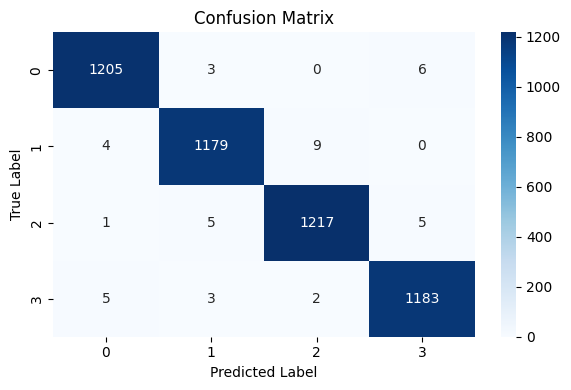

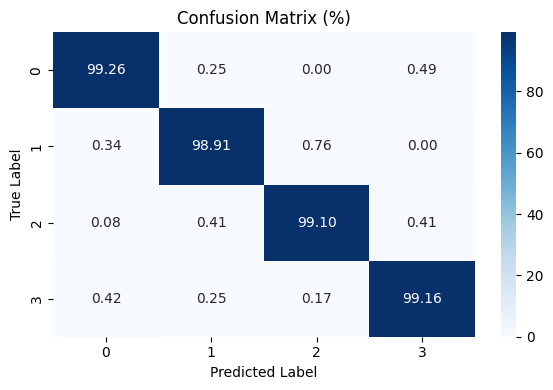


Per-Class Accuracy (%)
----------------------------------------
Class 0: 99.26%
Class 1: 98.91%
Class 2: 99.10%
Class 3: 99.16%
----------------------------------------
Overall Accuracy: 99.11%


In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# -----------------------------
# Test Evaluation
# -----------------------------
test_loss, test_acc = model.evaluate(
    X_test_res,
    y_test_res,
    verbose=0
)

print("="*50)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc*100:.2f}%")
print("="*50)

# -----------------------------
# Predictions
# -----------------------------
y_pred_prob = model.predict(X_test_res, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# -----------------------------
# Classification Report
# -----------------------------
print("\nClassification Report\n")

report = classification_report(
    y_test_res,
    y_pred,
    digits=4
)

print(report)

# Optional dataframe version
report_df = pd.DataFrame(
    classification_report(
        y_test_res,
        y_pred,
        output_dict=True
    )
).transpose()

report_df.to_csv("classification_report.csv")

# -----------------------------
# Confusion Matrix (Counts)
# -----------------------------
cm = confusion_matrix(y_test_res, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# -----------------------------
# Confusion Matrix (%)
# Row-wise normalization
# -----------------------------
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_percent = cm_percent * 100

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2f",
    cmap='Blues'
)

plt.title("Confusion Matrix (%)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# -----------------------------
# Save Percentage Matrix
# -----------------------------
cm_percent_df = pd.DataFrame(cm_percent)

cm_percent_df.to_csv(
    "confusion_matrix_percent.csv",
    index=False
)

# -----------------------------
# Per-Class Accuracy
# -----------------------------
class_accuracy = np.diag(cm) / cm.sum(axis=1)

print("\nPer-Class Accuracy (%)")
print("-"*40)

for idx, acc in enumerate(class_accuracy):
    print(f"Class {idx}: {acc*100:.2f}%")

print("-"*40)
print(f"Overall Accuracy: {accuracy_score(y_test_res, y_pred)*100:.2f}%")

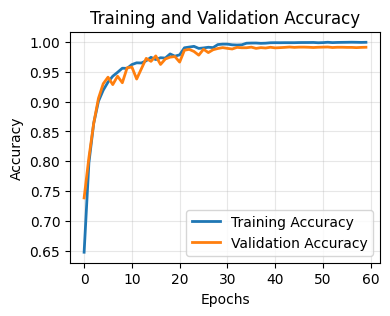

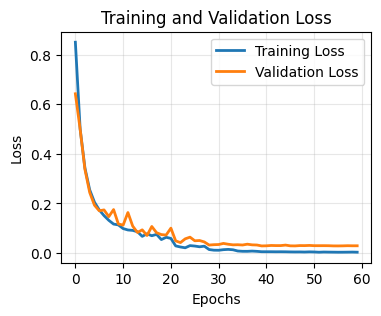

In [17]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(4,3))
plt.plot(
    history.history['accuracy'],
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    linewidth=2,
    label='Validation Accuracy'
)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Loss
plt.figure(figsize=(4,3))
plt.plot(
    history.history['loss'],
    linewidth=2,
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    linewidth=2,
    label='Validation Loss'
)

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

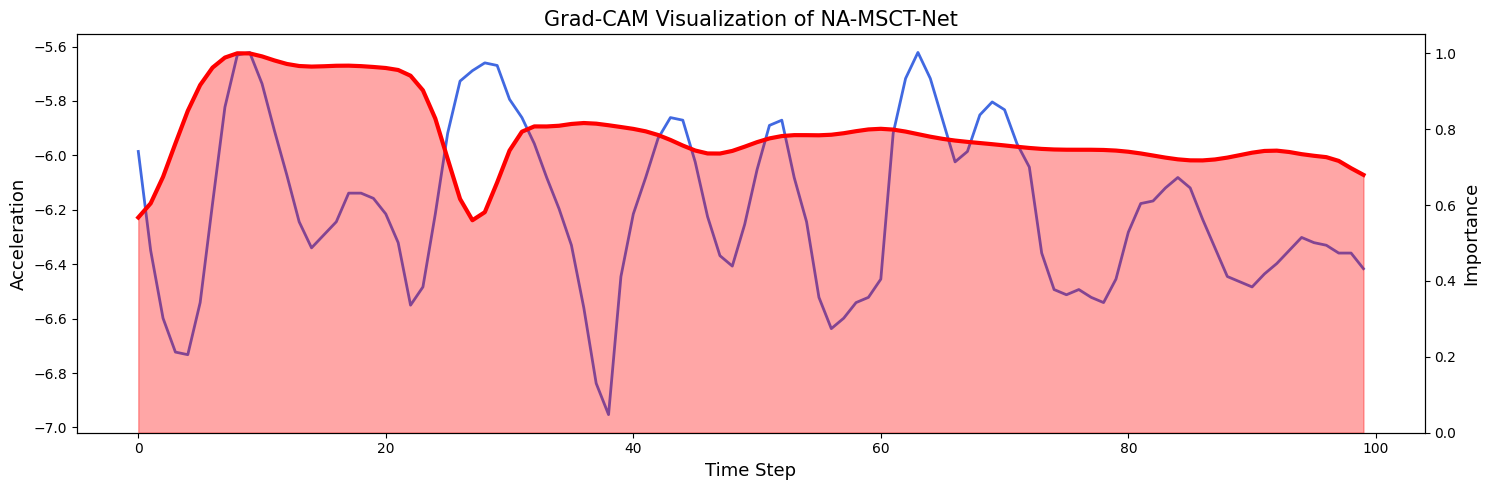

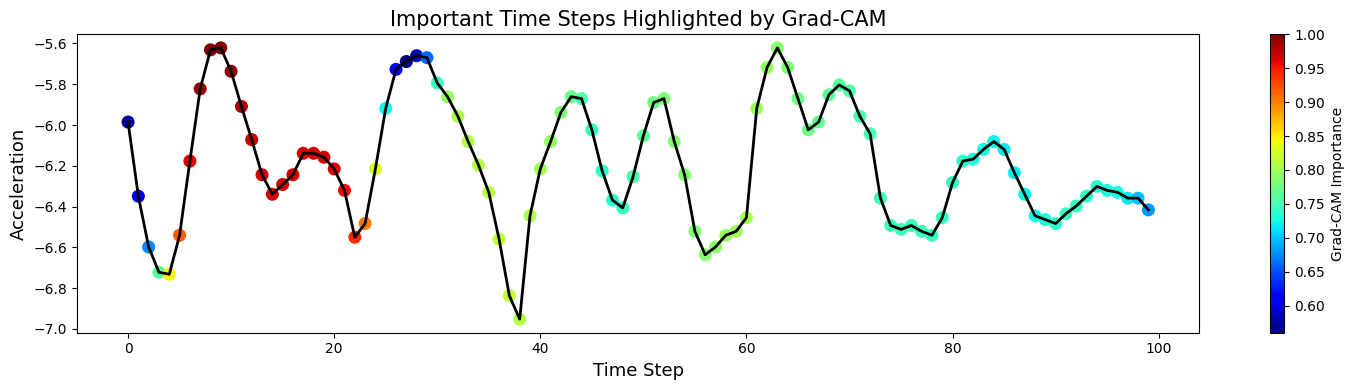

True Label      : 1
Predicted Label : 1
Confidence      : 0.9999894


In [24]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
#                Grad-CAM for 1D NA-MSCT-Net
# ============================================================

# -------- Select Sample --------
sample = 0

x = X_test_res[sample:sample+1]

# Raw Acc-X signal
signal = X_test_res[sample,:,0]

# ------------------------------------------------------------
# Build Gradient Model
# ------------------------------------------------------------

grad_model = tf.keras.models.Model(
    inputs=model.input,
    outputs=[
        model.get_layer("cnn7_gated").output,   # Last CNN feature map
        model.output
    ]
)

# ------------------------------------------------------------
# Compute Gradients
# ------------------------------------------------------------

with tf.GradientTape() as tape:

    conv_outputs, predictions = grad_model(x)

    pred_class = tf.argmax(predictions[0])

    loss = predictions[:, pred_class]

grads = tape.gradient(loss, conv_outputs)

# ------------------------------------------------------------
# Global Average Pooling of Gradients
# ------------------------------------------------------------

weights = tf.reduce_mean(
    grads,
    axis=1
)

conv_outputs = conv_outputs[0]

weights = weights[0]

# ------------------------------------------------------------
# Weighted Combination
# ------------------------------------------------------------

cam = tf.reduce_sum(
    conv_outputs * weights,
    axis=-1
)

cam = tf.nn.relu(cam)

cam = cam.numpy()

cam = cam / (cam.max() + 1e-8)

# ------------------------------------------------------------
# Smooth CAM
# ------------------------------------------------------------

from scipy.ndimage import gaussian_filter1d

cam = gaussian_filter1d(cam, sigma=2)

cam = cam / cam.max()

# ------------------------------------------------------------
# Plot 1
# ------------------------------------------------------------

fig, ax1 = plt.subplots(figsize=(15,5))

ax1.plot(
    signal,
    color='royalblue',
    linewidth=2,
    label='Acc-X'
)

ax1.set_xlabel("Time Step",fontsize=13)
ax1.set_ylabel("Acceleration",fontsize=13)

ax2 = ax1.twinx()

ax2.fill_between(
    np.arange(len(cam)),
    cam,
    alpha=0.35,
    color='red',
    label='Grad-CAM'
)

ax2.plot(
    cam,
    color='red',
    linewidth=3
)

ax2.set_ylabel(
    "Importance",
    fontsize=13
)

ax2.set_ylim([0,1.05])

plt.title(
    "Grad-CAM Visualization of NA-MSCT-Net",
    fontsize=15
)

fig.tight_layout()

plt.show()

# ------------------------------------------------------------
# Plot 2 (IEEE Sensors Style)
# ------------------------------------------------------------

plt.figure(figsize=(15,4))

plt.plot(
    signal,
    color='black',
    linewidth=2
)

plt.scatter(
    np.arange(len(signal)),
    signal,
    c=cam,
    cmap='jet',
    s=70
)

plt.colorbar(label="Grad-CAM Importance")

plt.xlabel("Time Step",fontsize=13)

plt.ylabel("Acceleration",fontsize=13)

plt.title(
    "Important Time Steps Highlighted by Grad-CAM",
    fontsize=15
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# Print Prediction
# ------------------------------------------------------------

prob = model.predict(x,verbose=0)

pred = np.argmax(prob)

print("True Label      :", y_test_res[sample])
print("Predicted Label :", pred)
print("Confidence      :", np.max(prob))

In [17]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import \
    convert_variables_to_constants_v2

def get_flops(model):

    concrete = tf.function(
        lambda x: model(x)
    ).get_concrete_function(
        tf.TensorSpec(
            [1] + list(model.input_shape[1:]),
            model.inputs[0].dtype
        )
    )

    frozen_func = convert_variables_to_constants_v2(
        concrete
    )

    graph_def = frozen_func.graph.as_graph_def()

    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(
            graph_def,
            name=''
        )

        run_meta = tf.compat.v1.RunMetadata()

        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd='op',
            options=opts
        )

    return flops.total_float_ops


flops = get_flops(model)

print("="*50)
print(f"FLOPs : {flops:,}")
print(f"MFLOPs: {flops/1e6:.3f}")
print(f"GFLOPs: {flops/1e9:.6f}")
print("="*50)

I0000 00:00:1784459901.366460      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1784459901.366658      58 single_machine.cc:374] Starting new session
I0000 00:00:1784459901.383522      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784459901.385143      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for the

In [20]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

import numpy as np
import pandas as pd
import gc
import time

# =====================================================
# SETTINGS
# =====================================================
INPUT_SHAPE = (100, 9)
NUM_CLASSES = len(np.unique(y_train_res))

# =====================================================
# CALLBACKS
# =====================================================
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6
    )
]

# =====================================================
# TRANSFORMER BLOCK
# =====================================================
def transformer_block(inputs):

    attn = layers.MultiHeadAttention(
        num_heads=2,
        key_dim=32,
        dropout=0.01
    )(inputs, inputs)

    x = layers.Add()([inputs, attn])
    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x)

    ffn = keras.Sequential([
        layers.Dense(
            64,
            activation='relu'
        ),
        layers.Dense(
            inputs.shape[-1]
        )
    ])

    x_ffn = ffn(x)

    x = layers.Add()([x, x_ffn])
    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x)

    return x


# =====================================================
# 1. CNN
# =====================================================
def build_cnn():

    inputs = keras.Input(shape=INPUT_SHAPE)

    x = layers.Conv1D(
        64,
        3,
        activation='relu',
        padding='same'
    )(inputs)

    x = layers.BatchNormalization()(x)

    x = layers.GlobalMaxPooling1D()(x)

    x = layers.Dense(
        128,
        activation='relu'
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    return keras.Model(inputs, outputs, name='CNN')


# =====================================================
# 2. LSTM
# =====================================================
def build_lstm():

    inputs = keras.Input(shape=INPUT_SHAPE)

    x = layers.LSTM(64)(inputs)

    x = layers.Dense(
        128,
        activation='relu'
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    return keras.Model(inputs, outputs, name='LSTM')


# =====================================================
# 3. BiLSTM
# =====================================================
def build_bilstm():

    inputs = keras.Input(shape=INPUT_SHAPE)

    x = layers.Bidirectional(
        layers.LSTM(32)
    )(inputs)

    x = layers.Dense(
        128,
        activation='relu'
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    return keras.Model(inputs, outputs, name='BiLSTM')


# =====================================================
# 4. CNN-LSTM
# =====================================================
def build_cnn_lstm():

    inputs = keras.Input(shape=INPUT_SHAPE)

    x = layers.Conv1D(
        64,
        3,
        activation='relu',
        padding='same'
    )(inputs)

    x = layers.BatchNormalization()(x)

    x = layers.LSTM(64)(x)

    x = layers.Dense(
        128,
        activation='relu'
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    return keras.Model(inputs, outputs, name='CNN-LSTM')


# =====================================================
# 5. CNN-BiLSTM
# =====================================================
def build_cnn_bilstm():

    inputs = keras.Input(shape=INPUT_SHAPE)

    x = layers.Conv1D(
        64,
        3,
        activation='relu',
        padding='same'
    )(inputs)

    x = layers.BatchNormalization()(x)

    x = layers.Bidirectional(
        layers.LSTM(32)
    )(x)

    x = layers.Dense(
        128,
        activation='relu'
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    return keras.Model(inputs, outputs, name='CNN-BiLSTM')


# =====================================================
# 6. Transformer
# =====================================================
def build_transformer():

    inputs = keras.Input(shape=INPUT_SHAPE)

    x = transformer_block(inputs)

    x = layers.GlobalMaxPooling1D()(x)

    x = layers.Dense(
        128,
        activation='relu'
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    return keras.Model(inputs, outputs, name='Transformer')


# =====================================================
# 7. CNN-Transformer
# =====================================================
def build_cnn_transformer():

    inputs = keras.Input(shape=INPUT_SHAPE)

    x = layers.Conv1D(
        64,
        3,
        activation='relu',
        padding='same'
    )(inputs)

    x = layers.BatchNormalization()(x)

    cnn1 = layers.Conv1D(
        64,
        3,
        activation='relu',
        padding='same'
    )(x)

    cnn2 = layers.Conv1D(
        64,
        5,
        activation='relu',
        padding='same'
    )(x)

    cnn3 = layers.Conv1D(
        64,
        7,
        activation='relu',
        padding='same'
    )(x)

    trans = transformer_block(x)

    x = layers.Concatenate()(
        [cnn1, cnn2, cnn3, trans]
    )

    x = layers.GlobalMaxPooling1D()(x)

    x = layers.Dense(
        128,
        activation='relu'
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    return keras.Model(
        inputs,
        outputs,
        name='CNN-Transformer'
    )


# =====================================================
# MODEL DICTIONARY
# =====================================================
models = {
    'CNN': build_cnn,
    'LSTM': build_lstm,
    'BiLSTM': build_bilstm,
    'CNN-LSTM': build_cnn_lstm,
    'CNN-BiLSTM': build_cnn_bilstm,
    'Transformer': build_transformer,
    'CNN-Transformer': build_cnn_transformer
}


histories = {}
trained_models = {}

# =====================================================
# TRAIN ALL MODELS
# =====================================================
for name, builder in models.items():

    print('\n' + '='*70)
    print(f'Training {name}')
    print('='*70)

    tf.keras.backend.clear_session()
    gc.collect()

    model = builder()

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    start = time.time()

    history = model.fit(
        X_train_res,
        y_train_res,
        validation_data=(
            X_test_res,
            y_test_res
        ),
        epochs=100,
        batch_size=128,
        callbacks=callbacks,
        verbose=1
    )

    end = time.time()

    histories[name] = history
    trained_models[name] = model

    print(
        f'{name} Training Time: '
        f'{(end-start)/60:.2f} mins'
    )


Training CNN
Epoch 1/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4920 - loss: 1.1742 - val_accuracy: 0.5333 - val_loss: 1.0660 - learning_rate: 0.0010
Epoch 2/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5893 - loss: 0.9647 - val_accuracy: 0.6024 - val_loss: 0.9512 - learning_rate: 0.0010
Epoch 3/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6318 - loss: 0.8793 - val_accuracy: 0.6414 - val_loss: 0.8529 - learning_rate: 0.0010
Epoch 4/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6674 - loss: 0.8116 - val_accuracy: 0.6613 - val_loss: 0.8158 - learning_rate: 0.0010
Epoch 5/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6983 - loss: 0.7479 - val_accuracy: 0.6915 - val_loss: 0.7635 - learning_rate: 0.0010
Epoch 6/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7160 - loss: 0.6979 - val_accuracy: 0.7158 - val_loss: 0.6977 - learning_rate: 0.0010
Epoch 7/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.

In [21]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import \
    convert_variables_to_constants_v2


def get_flops(model):

    concrete = tf.function(
        lambda x: model(x)
    ).get_concrete_function(
        tf.TensorSpec(
            [1] + list(model.input_shape[1:]),
            model.inputs[0].dtype
        )
    )

    frozen_func = convert_variables_to_constants_v2(
        concrete
    )

    graph_def = frozen_func.graph.as_graph_def()

    with tf.Graph().as_default() as graph:

        tf.graph_util.import_graph_def(
            graph_def,
            name=''
        )

        run_meta = tf.compat.v1.RunMetadata()

        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd='op',
            options=opts
        )

    return flops.total_float_ops

In [22]:
from sklearn.metrics import (
    classification_report,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
import pandas as pd
import numpy as np
import time

results = []

for name, model in trained_models.items():

    print('\n' + '='*70)
    print(name)
    print('='*70)

    # -------------------------
    # Evaluation
    # -------------------------
    loss, acc = model.evaluate(
        X_test_res,
        y_test_res,
        verbose=0
    )

    # -------------------------
    # Inference Time
    # -------------------------
    start = time.time()

    y_prob = model.predict(
        X_test_res,
        verbose=0
    )

    inference_time = time.time() - start

    per_sample_time = (
        inference_time /
        len(X_test_res)
    ) * 1000

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    print(
        classification_report(
            y_test_res,
            y_pred,
            digits=4
        )
    )

    # -------------------------
    # AUC
    # -------------------------
    y_test_bin = label_binarize(
        y_test_res,
        classes=np.arange(NUM_CLASSES)
    )

    auc = roc_auc_score(
        y_test_bin,
        y_prob,
        average='macro',
        multi_class='ovr'
    )

    # -------------------------
    # Parameters
    # -------------------------
    params = model.count_params()

    # -------------------------
    # FLOPs
    # -------------------------
    try:
        flops = get_flops(model)
    except:
        flops = np.nan

    # -------------------------
    # Store Results
    # -------------------------
    results.append({

        'Model': name,

        'Accuracy (%)':
            round(acc*100, 2),

        'Loss':
            round(loss, 4),

        'AUC':
            round(auc, 4),

        'Parameters':
            f'{params:,}',

        'FLOPs':
            f'{flops:,}',

        'MFLOPs':
            round(flops/1e6, 3)
            if not np.isnan(flops)
            else np.nan,

        'Inference (ms/sample)':
            round(per_sample_time, 4)
    })

results_df = pd.DataFrame(results)

print(results_df)

results_df.to_csv(
    'benchmark_results.csv',
    index=False
)


CNN
              precision    recall  f1-score   support

           0     0.9751    0.9671    0.9711      1214
           1     0.9250    0.9413    0.9331      1192
           2     0.9435    0.9251    0.9342      1228
           3     0.9602    0.9707    0.9654      1193

    accuracy                         0.9509      4827
   macro avg     0.9509    0.9510    0.9509      4827
weighted avg     0.9510    0.9509    0.9509      4827


LSTM

=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes        

I0000 00:00:1782564503.594660      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1782564503.594803      58 single_machine.cc:374] Starting new session
I0000 00:00:1782564503.595656      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


              precision    recall  f1-score   support

           0     0.7384    0.6582    0.6960      1214
           1     0.5312    0.5218    0.5264      1192
           2     0.5695    0.5936    0.5813      1228
           3     0.6623    0.7184    0.6892      1193

    accuracy                         0.6230      4827
   macro avg     0.6254    0.6230    0.6232      4827
weighted avg     0.6255    0.6230    0.6233      4827


BiLSTM

=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          


I0000 00:00:1782564505.192353      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1782564505.192541      58 single_machine.cc:374] Starting new session
I0000 00:00:1782564505.193521      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


              precision    recall  f1-score   support

           0     0.6458    0.6458    0.6458      1214
           1     0.6286    0.4799    0.5442      1192
           2     0.5767    0.6857    0.6265      1228
           3     0.6750    0.7033    0.6888      1193

    accuracy                         0.6292      4827
   macro avg     0.6315    0.6287    0.6263      4827
weighted avg     0.6312    0.6292    0.6264      4827



...

I0000 00:00:1782564511.487255      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1782564511.487420      58 single_machine.cc:374] Starting new session
I0000 00:00:1782564511.488262      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

I0000 00:00:1782564514.997408      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1782564514.997562      58 single_machine.cc:374] Starting new session
I0000 00:00:1782564514.998468      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


              precision    recall  f1-score   support

           0     0.9869    0.9918    0.9893      1214
           1     0.9823    0.9799    0.9811      1192
           2     0.9805    0.9829    0.9817      1228
           3     0.9924    0.9874    0.9899      1193

    accuracy                         0.9855      4827
   macro avg     0.9855    0.9855    0.9855      4827
weighted avg     0.9855    0.9855    0.9855      4827

             Model  Accuracy (%)    Loss     AUC Parameters       FLOPs  \
0              CNN         95.09  0.1555  0.9947     10,884     382,744   
1             LSTM         62.30  0.8766  0.8647     27,780      17,560   
2           BiLSTM         62.92  0.8901  0.8636     19,588      17,560   
3         CNN-LSTM         57.20  0.9184  0.8455     43,908     382,744   
4       CNN-BiLSTM         60.49  0.9117  0.8577     35,716     382,744   
5      Transformer         44.77  1.1446  0.7637      5,562   3,407,280   
6  CNN-Transformer         98.55  0.0570

I0000 00:00:1782564519.614326      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1782564519.614573      58 single_machine.cc:374] Starting new session
I0000 00:00:1782564519.615692      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [23]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
import pandas as pd
import numpy as np

results = []

for name, model in trained_models.items():

    print('\n' + '='*70)
    print(name)
    print('='*70)

    loss, acc = model.evaluate(
        X_test_res,
        y_test_res,
        verbose=0
    )

    y_prob = model.predict(
        X_test_res,
        verbose=0
    )

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    print(
        classification_report(
            y_test_res,
            y_pred,
            digits=4
        )
    )

    y_test_bin = label_binarize(
        y_test_res,
        classes=np.arange(NUM_CLASSES)
    )

    auc = roc_auc_score(
        y_test_bin,
        y_prob,
        average='macro',
        multi_class='ovr'
    )

    params = model.count_params()

    results.append({
        'Model': name,
        'Accuracy': acc*100,
        'Loss': loss,
        'AUC': auc,
        'Parameters': params
    })

results_df = pd.DataFrame(results)

print(results_df)

results_df.to_csv(
    'benchmark_results.csv',
    index=False
)


CNN
              precision    recall  f1-score   support

           0     0.9751    0.9671    0.9711      1214
           1     0.9250    0.9413    0.9331      1192
           2     0.9435    0.9251    0.9342      1228
           3     0.9602    0.9707    0.9654      1193

    accuracy                         0.9509      4827
   macro avg     0.9509    0.9510    0.9509      4827
weighted avg     0.9510    0.9509    0.9509      4827


LSTM
              precision    recall  f1-score   support

           0     0.7384    0.6582    0.6960      1214
           1     0.5312    0.5218    0.5264      1192
           2     0.5695    0.5936    0.5813      1228
           3     0.6623    0.7184    0.6892      1193

    accuracy                         0.6230      4827
   macro avg     0.6254    0.6230    0.6232      4827
weighted avg     0.6255    0.6230    0.6233      4827


BiLSTM
              precision    recall  f1-score   support

           0     0.6458    0.6458    0.6458      1214
  

In [23]:
import tensorflow as tf
from tensorflow import keras
import h5py
import numpy as np

# =====================================================
# Rebuild your model architecture first
# (Make sure build_na_msct_net() is already defined)
# =====================================================
model = build_na_msct_net(
    input_shape=(100, 9),
    num_classes=4
)

# =====================================================
# Load saved model/weights
# =====================================================
model_path = "/kaggle/working/best_na_msct_model.h5"

try:
    # Try loading as weights
    model.load_weights(model_path)
    print("Weights loaded successfully.")

except:
    print("Could not load as weights. Trying full model...")

    tf.keras.config.enable_unsafe_deserialization()

    model = keras.models.load_model(
        model_path,
        compile=False,
        safe_mode=False
    )

# =====================================================
# Compile
# =====================================================
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

# =====================================================
# Evaluate
# =====================================================
test_loss, test_acc = model.evaluate(
    X_test_res,
    y_test_res,
    verbose=0
)

print("="*50)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc*100:.2f}%")
print("="*50)

# =====================================================
# Predictions
# =====================================================
y_prob = model.predict(
    X_test_res,
    verbose=0
)

y_pred = np.argmax(
    y_prob,
    axis=1
)

Weights loaded successfully.


Model: "NA-MSCT-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 100, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 100, 32)   │        896 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 32)   │        128 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 100, 64)   │      1,792 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 100, 1)    │         97 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 64)   │        256 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 100, 1)    │          0 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_6          │ (None, 100, 64)   │          0 │ batch_normalizat… │
│ (Multiply)          │                   │            │ lambda_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 100, 64)   │     16,640 │ multiply_6[0][0], │
│ (MultiHeadAttentio… │                   │            │ multiply_6[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_9 (Lambda)   │ (None, 100, 1)    │          0 │ conv1d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_10         │ (None, 100, 64)   │          0 │ multi_head_atten… │
│ (Multiply)          │                   │            │ lambda_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 100, 64)   │          0 │ multiply_10[0][0… │
│                     │                   │            │ multiply_6[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 64)   │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 100, 64)   │      8,320 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 100, 64)   │     12,352 │ multiply_6[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 100, 64)   │     20,544 │ multiply_6[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 100, 64)   │     28,736 │ multiply_6[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_11         │ (None, 100, 64)   │          0 │ sequential_1[0][… │
│ (Multiply)          │                   │            │ lambda_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 100, 64)   │        256 │ conv1d_9[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 124,197 (485.14 KB)

 Trainable params: 123,621 (482.89 KB)

 Non-trainable params: 576 (2.25 KB)

None
Test Loss     : 0.0378
Test Accuracy : 99.21%


ABlation

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
import pandas as pd
import numpy as np
import gc

NUM_CLASSES = len(np.unique(y_train_res))
INPUT_SHAPE = X_train_res.shape[1:]

# ======================================================
# Modules
# ======================================================
def noise_estimation_module(inputs):
    x = layers.Conv1D(
        32,
        3,
        padding='same',
        activation='relu'
    )(inputs)

    x = layers.BatchNormalization()(x)

    noise = layers.Conv1D(
        1,
        3,
        padding='same',
        activation='softplus'
    )(x)

    return noise


def noise_aware_gating(features, noise):
    weight = layers.Lambda(
        lambda x: tf.exp(-x)
    )(noise)

    return layers.Multiply()([features, weight])


def transformer_encoder(
    inputs,
    noise=None,
    use_noise=False
):

    attn = layers.MultiHeadAttention(
        num_heads=2,
        key_dim=32,
        dropout=0.01
    )(inputs, inputs)

    if use_noise:
        weight = layers.Lambda(
            lambda x: tf.exp(-x)
        )(noise)

        attn = layers.Multiply()(
            [attn, weight]
        )

    x = layers.Add()([inputs, attn])
    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x)

    ffn = keras.Sequential([
        layers.Dense(
            64,
            activation='relu'
        ),
        layers.Dense(
            inputs.shape[-1]
        )
    ])

    x_ffn = ffn(x)

    if use_noise:
        x_ffn = layers.Multiply()(
            [x_ffn, weight]
        )

    x = layers.Add()([x, x_ffn])

    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x)

    return x


# ======================================================
# Ablation Model Builder
# ======================================================
def build_model(
    use_nem=False,
    use_cnn_gate=False,
    use_trans_gate=False
):

    inputs = keras.Input(
        shape=INPUT_SHAPE
    )

    noise = None

    if use_nem:
        noise = noise_estimation_module(
            inputs
        )

    # Global CNN
    x = layers.Conv1D(
        64,
        3,
        padding='same',
        activation='relu'
    )(inputs)

    x = layers.BatchNormalization()(x)

    if use_cnn_gate and noise is not None:
        x = noise_aware_gating(
            x,
            noise
        )

    branches = []

    for k in [3,5,7]:

        b = layers.Conv1D(
            64,
            k,
            padding='same',
            activation='relu'
        )(x)

        b = layers.BatchNormalization()(b)

        if use_cnn_gate and noise is not None:
            b = noise_aware_gating(
                b,
                noise
            )

        branches.append(b)

    transformer = transformer_encoder(
        x,
        noise=noise,
        use_noise=use_trans_gate
    )

    x = layers.Concatenate()(
        branches + [transformer]
    )

    x = layers.GlobalMaxPooling1D()(x)

    x = layers.Dense(
        128,
        activation='relu'
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    return keras.Model(
        inputs,
        outputs
    )


# ======================================================
# Ablation Settings
# ======================================================
settings = {
    'Baseline':
        (False, False, False),

    '+NEM':
        (True, False, False),

    '+NAG':
        (True, True, False),

    '+NATE':
        (True, False, True),

    '+NAG + NATE':
        (True, True, True)
}


results = []

baseline_acc = None

for name, config in settings.items():

    print("\n" + "="*70)
    print(name)
    print("="*70)

    tf.keras.backend.clear_session()
    gc.collect()

    model = build_model(*config)

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train_res,
        y_train_res,
        validation_data=(
            X_test_res,
            y_test_res
        ),
        epochs=100,
        batch_size=128,
        verbose=1
    )

    y_prob = model.predict(
        X_test_res,
        verbose=0
    )

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    acc = accuracy_score(
        y_test_res,
        y_pred
    ) * 100

    f1 = f1_score(
        y_test_res,
        y_pred,
        average='macro'
    ) * 100

    y_test_bin = label_binarize(
        y_test_res,
        classes=np.arange(NUM_CLASSES)
    )

    auc = roc_auc_score(
        y_test_bin,
        y_prob,
        average='macro',
        multi_class='ovr'
    )

    if baseline_acc is None:
        baseline_acc = acc

    delta = acc - baseline_acc

    results.append({
        'Setting': name,
        'Acc (%)': round(acc,2),
        'F1-score (%)': round(f1,2),
        'AUC': round(auc,4),
        'ΔAcc (%)': round(delta,2)
    })

    del model
    gc.collect()
    tf.keras.backend.clear_session()

ablation_df = pd.DataFrame(results)

print(ablation_df)



2026-06-28 08:46:07.561111: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782636367.755025      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782636367.808891      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782636368.249780      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782636368.249813      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782636368.249816      58 computation_placer.cc:177] computation placer alr


Baseline


I0000 00:00:1782636380.750333      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1782636387.216715     143 service.cc:152] XLA service 0x78b12840b530 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782636387.216788     143 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782636388.220666     143 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782636393.638128     143 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



+NEM

+NAG

+NATE

+NAG + NATE
       Setting  Acc (%)  F1-score (%)     AUC  ΔAcc (%)
0     Baseline    98.05         98.05  0.9990      0.00
1         +NEM    97.74         97.74  0.9984     -0.31
2         +NAG    98.32         98.33  0.9992      0.27
3        +NATE    98.28         98.28  0.9993      0.23
4  +NAG + NATE    96.48         96.48  0.9982     -1.57


In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
import pandas as pd
import numpy as np
import gc

NUM_CLASSES = len(np.unique(y_train_res))
INPUT_SHAPE = X_train_res.shape[1:]

# ======================================================
# Noise Estimation Module
# ======================================================
def noise_estimation_module(inputs):

    x = layers.Conv1D(
        32,
        3,
        padding='same',
        activation='relu'
    )(inputs)

    x = layers.BatchNormalization()(x)

    noise = layers.Conv1D(
        1,
        3,
        padding='same',
        activation='softplus'
    )(x)

    return noise


# ======================================================
# Noise-Aware Gating
# ======================================================
def noise_aware_gating(features, noise):

    weight = layers.Lambda(
        lambda x: tf.exp(-x)
    )(noise)

    return layers.Multiply()(
        [features, weight]
    )


# ======================================================
# Transformer Encoder
# ======================================================
def transformer_encoder(
    inputs,
    noise=None,
    use_noise=False
):

    attn = layers.MultiHeadAttention(
        num_heads=2,
        key_dim=32,
        dropout=0.01
    )(inputs, inputs)

    if use_noise:

        weight = layers.Lambda(
            lambda x: tf.exp(-x)
        )(noise)

        attn = layers.Multiply()(
            [attn, weight]
        )

    x = layers.Add()([inputs, attn])

    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x)

    ffn = keras.Sequential([
        layers.Dense(
            64,
            activation='relu'
        ),
        layers.Dense(
            inputs.shape[-1]
        )
    ])

    x_ffn = ffn(x)

    if use_noise:
        x_ffn = layers.Multiply()(
            [x_ffn, weight]
        )

    x = layers.Add()([x, x_ffn])

    x = layers.LayerNormalization(
        epsilon=1e-6
    )(x)

    return x


# ======================================================
# Ablation Model Builder
# ======================================================
def build_model(
    use_nem=False,
    use_cnn_gate=False,
    use_trans_gate=False
):

    inputs = keras.Input(
        shape=INPUT_SHAPE
    )

    noise = None

    if use_nem:
        noise = noise_estimation_module(
            inputs
        )

    # Global CNN
    x = layers.Conv1D(
        64,
        3,
        padding='same',
        activation='relu'
    )(inputs)

    x = layers.BatchNormalization()(x)

    if use_cnn_gate and noise is not None:
        x = noise_aware_gating(
            x,
            noise
        )

    branches = []

    for k in [3, 5, 7]:

        b = layers.Conv1D(
            64,
            k,
            padding='same',
            activation='relu'
        )(x)

        b = layers.BatchNormalization()(b)

        if use_cnn_gate and noise is not None:
            b = noise_aware_gating(
                b,
                noise
            )

        branches.append(b)

    transformer = transformer_encoder(
        x,
        noise=noise,
        use_noise=use_trans_gate
    )

    x = layers.Concatenate()(
        branches + [transformer]
    )

    x = layers.GlobalMaxPooling1D()(x)

    x = layers.Dense(
        128,
        activation='relu'
    )(x)

    outputs = layers.Dense(
        NUM_CLASSES,
        activation='softmax'
    )(x)

    return keras.Model(
        inputs,
        outputs
    )


# ======================================================
# Ablation Settings
# ======================================================
settings = {
    'Baseline':
        (False, False, False),

    '+NEM':
        (True, False, False),

    '+NAG':
        (True, True, False),

    '+NATE':
        (True, False, True),

    '+NAG + NATE':
        (True, True, True)
}


# ======================================================
# Run Ablation
# ======================================================
results = []

baseline_acc = None

for name, config in settings.items():

    print("\n" + "="*70)
    print(name)
    print("="*70)

    tf.keras.backend.clear_session()
    gc.collect()

    model = build_model(*config)

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_train_res,
        y_train_res,
        validation_data=(
            X_test_res,
            y_test_res
        ),
        epochs=100,
        batch_size=128,
        verbose=1
    )

    # ==================================================
    # Test Evaluation
    # ==================================================
    test_loss, test_acc = model.evaluate(
        X_test_res,
        y_test_res,
        verbose=0
    )

    y_prob = model.predict(
        X_test_res,
        verbose=0
    )

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    acc = accuracy_score(
        y_test_res,
        y_pred
    ) * 100

    f1 = f1_score(
        y_test_res,
        y_pred,
        average='macro'
    ) * 100

    y_test_bin = label_binarize(
        y_test_res,
        classes=np.arange(NUM_CLASSES)
    )

    auc = roc_auc_score(
        y_test_bin,
        y_prob,
        average='macro',
        multi_class='ovr'
    )

    if baseline_acc is None:
        baseline_acc = acc

    delta = acc - baseline_acc

    results.append({
        'Setting': name,
        'Acc (%)': round(acc, 2),
        'F1-score (%)': round(f1, 2),
        'Loss': round(test_loss, 4),
        'AUC': round(auc, 4),
        'ΔAcc (%)': round(delta, 2)
    })

    del model
    gc.collect()
    tf.keras.backend.clear_session()


# ======================================================
# Final Results
# ======================================================
ablation_df = pd.DataFrame(results)

print("\n")
print(ablation_df)

ablation_df.to_csv(
    'ablation_results.csv',
    index=False
)

2026-06-28 17:45:29.784741: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782668729.943448      59 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782668729.991565      59 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782668730.391576      59 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782668730.391607      59 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782668730.391609      59 computation_placer.cc:177] computation placer alr


Baseline


I0000 00:00:1782668742.596835      59 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/100


I0000 00:00:1782668749.021183     131 service.cc:152] XLA service 0x7bed30008770 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782668749.021223     131 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782668749.986822     131 cuda_dnn.cc:529] Loaded cuDNN version 91002


 25/151 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3765 - loss: 1.7665

I0000 00:00:1782668755.315816     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


151/151 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - accuracy: 0.5982 - loss: 0.9781 - val_accuracy: 0.6391 - val_loss: 0.8315
Epoch 2/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7146 - loss: 0.6884 - val_accuracy: 0.7508 - val_loss: 0.6101
Epoch 3/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7617 - loss: 0.5726 - val_accuracy: 0.8121 - val_loss: 0.4922
Epoch 4/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8079 - loss: 0.4723 - val_accuracy: 0.7930 - val_loss: 0.5101
Epoch 5/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8342 - loss: 0.4053 - val_accuracy: 0.8411 - val_loss: 0.4161
Epoch 6/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8740 - loss: 0.3318 - val_accuracy: 0.8680 - val_loss: 0.3226
Epoch 7/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8882 - loss: 0.2918 - val_accuracy: 0.8832 - val_loss: 0.3059
Epoch 8/100
151/151 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8980 - loss: 0.2610 - val_accuracy: 0.91